In [1]:
# CODE and OUTPUT
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

# Read dataset
df = pd.read_csv("SAMPLEIDS.csv")
df
df.head()
df.tail()
df.info()
df.describe()
df.isnull().sum()
df.isnull().any()

df.dropna()
df.fillna(0)
df.fillna(method='ffill')
df.fillna({'GENDER':'MALE','NAME':'SRI'})



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   SNO      21 non-null     int64  
 1   REGNO    21 non-null     int64  
 2   NAME     20 non-null     object 
 3   DOB      21 non-null     object 
 4   GENDER   20 non-null     object 
 5   ADDRESS  20 non-null     object 
 6   M1       18 non-null     float64
 7   M2       19 non-null     float64
 8   M3       17 non-null     float64
 9   M4       18 non-null     float64
 10  TOTAL    16 non-null     float64
 11  AVG      20 non-null     float64
dtypes: float64(6), int64(2), object(4)
memory usage: 2.1+ KB


,SNO,REGNO,NAME,DOB,GENDER,ADDRESS,M1,M2,M3,M4,TOTAL,AVG
0,1,1220121,ARUN,2000-02-10,MALE,THANDALAM,82.0,81.0,90.0,NaN,NaN,NaN
1,2,1220122,BABU,1999-01-25,MALE,KANCHIPURAM,56.0,61.0,80.0,56.0,253.0,84.333333
2,3,1220123,CHARAN,2000.09.21,MALE,THANDALAM,NaN,59.0,60.0,70.0,NaN,0.000000
3,4,1220124,DEVA,2000-11-09,MALE,POONAMALEE,74.0,79.0,80.0,74.0,307.0,102.333333
4,5,1220125,ESTER,2000-11-21,FEMALE,CHITHUR,92.0,95.0,96.0,92.0,375.0,125.000000
5,6,1220126,FARHANA,1999-03-05,FEMALE,THANDALAM,91.0,88.0,90.0,91.0,360.0,120.000000
6,7,1220127,GANI,2000-10-02,MALE,KANCHIPURAM,49.0,51.0,70.0,49.0,219.0,73.000000
7,7,1220127,GANI,2000-10-02,MALE,KANCHIPURAM,49.0,51.0,70.0,49.0,219.0,73.000000
8,8,1220128,HEMA,1999-01-25,FEMALE,POONAMALEE,95.0,96.0,90.0,95.0,376.0,125.333333
9,9,1220129,INDRA,2000.09.21,FEMALE,KANCHIPURAM,64.0,NaN,NaN,64.0,NaN,0.000000


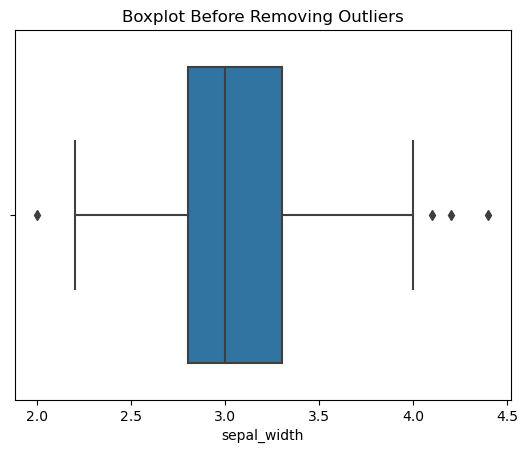

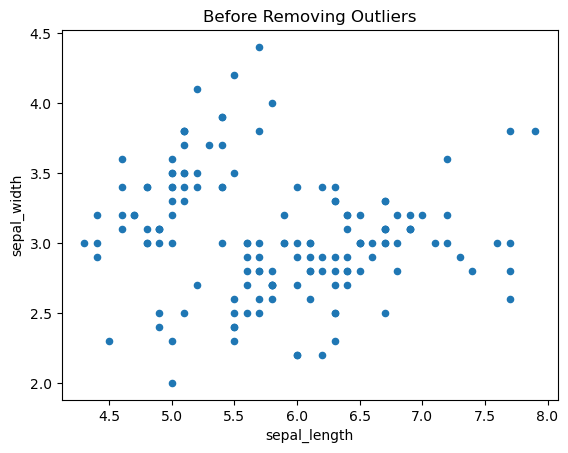

0.5


In [2]:
# Iris dataset
ir = pd.read_csv("iris.csv")
ir
ir.describe()

sns.boxplot(x='sepal_width', data=ir)
plt.title("Boxplot Before Removing Outliers")
plt.show()

ir.plot.scatter(x='sepal_length', y='sepal_width', title="Before Removing Outliers")
plt.show()


Q1 = ir.sepal_width.quantile(0.25)
Q3 = ir.sepal_width.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

In [3]:
# Find Outliers
outliers = ir[((ir.sepal_width < (Q1 - 1.5 * IQR)) | (ir.sepal_width > (Q3 + 1.5 * IQR)))]
print("Outliers:\n", outliers['sepal_width'])

# Remove outliers (using ~ to negate the condition)
ran = ir[~((ir.sepal_width < (Q1 - 1.5 * IQR)) | (ir.sepal_width > (Q3 + 1.5 * IQR)))]
print("Cleaned Data (IQR):\n", ran['sepal_width'].head())

Outliers:
 15    4.4
32    4.1
33    4.2
60    2.0
Name: sepal_width, dtype: float64
Cleaned Data (IQR):
 0    3.5
1    3.0
2    3.2
3    3.1
4    3.6
Name: sepal_width, dtype: float64


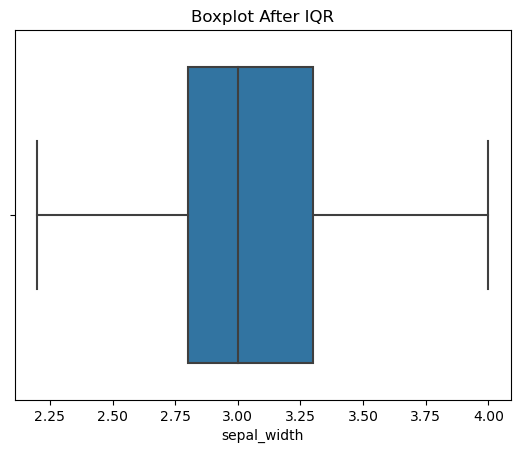

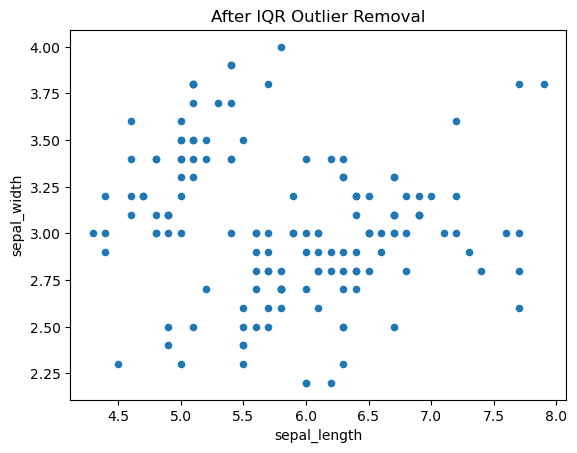

In [4]:
# Plot After IQR
sns.boxplot(x='sepal_width', data=ran)
plt.title("Boxplot After IQR")
plt.show()

ran.plot.scatter(x='sepal_length', y='sepal_width', title="After IQR Outlier Removal")
plt.show()


Z-scores:
 0      1.341272
1      1.341272
2      1.398138
3      1.284407
4      1.341272
         ...   
145    0.819624
146    0.705893
147    0.819624
148    0.933356
149    0.762759
Name: petal_length, Length: 150, dtype: float64
Cleaned Data (Z-Score):
    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


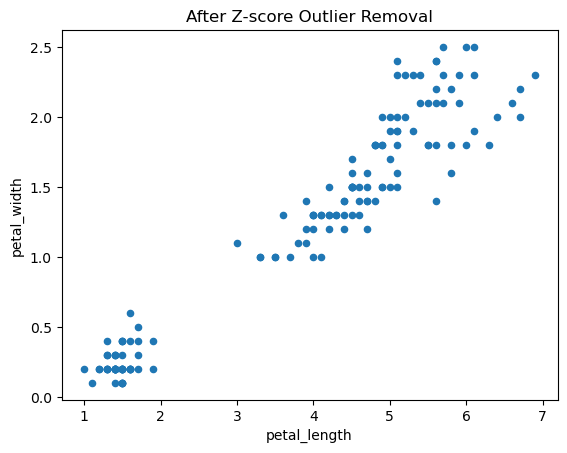

In [5]:
# --- 4. Z-SCORE OUTLIER REMOVAL (petal_length) ---
z = np.abs(stats.zscore(ir['petal_length']))
print("Z-scores:\n", z)

# Keep data where z-score is less than 3
ir1 = ir[z < 3]
print("Cleaned Data (Z-Score):\n", ir1.head())

ir1.plot.scatter(x='petal_length', y='petal_width', title="After Z-score Outlier Removal")
plt.show()